---
## 1. Кітапханалар мен баптаулар

In [ ]:
#!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score,  StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.ensemble import (
    ExtraTreesClassifier, GradientBoostingClassifier,
    RandomForestClassifier, VotingClassifier
)
from sklearn.svm import SVC
from sklearn.utils import resample
import joblib

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FB',
    'axes.edgecolor':    '#D0D7DE',
    'axes.labelcolor':   '#24292F',
    'axes.labelsize':    11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#24292F',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'text.color':        '#24292F',
    'xtick.color':       '#57606A',
    'ytick.color':       '#57606A',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'grid.color':        '#E6EBF1',
    'grid.linewidth':    0.9,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#D0D7DE',
    'legend.fontsize':   9,
    'figure.dpi':        110,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ─── Түс палитралары ──────────────────────────────
STRESS5_COLORS = {1:'#2DA44E', 2:'#54AAB4', 3:'#F0A400', 4:'#E16F24', 5:'#CF222E'}
STRESS3_COLORS = {0:'#2DA44E', 1:'#F0A400', 2:'#CF222E'}
STRESS3_NAMES  = {0:'Low', 1:'Medium', 2:'High'}
MODEL_COLORS  = {
    'Extra Trees':       '#2DA44E',
    'Gradient Boosting': '#0969DA',
    'Random Forest':     '#CF222E',
    'SVM':               '#8250DF',
    'Voting Ensemble':   '#E16F24',
}

print('Кітапханалар жүктелді, ашық тақырып белсендірілді')

Кітапханалар жүктелді, ашық тақырып белсендірілді


---
## 2. Деректерді жүктеу және шолу

In [ ]:
df = pd.read_csv('/content/academic Stress level - maintainance 1.csv')
df.columns = [
    'timestamp', 'level', 'peer_pressure', 'parental_pressure',
    'environment', 'coping_strategy', 'harmful_habits',
    'competition', 'stress_level'
]

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(20)

Dataset loaded: 140 rows × 9 columns


,timestamp,level,peer_pressure,parental_pressure,environment,coping_strategy,harmful_habits,competition,stress_level
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5
5,24/07/2025 22:08:13,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,4
6,24/07/2025 22:09:21,undergraduate,5,5,disrupted,Emotional breakdown (crying a lot),No,4,4
7,24/07/2025 22:10:06,undergraduate,3,2,Peaceful,"Social support (friends, family)",No,3,3
8,24/07/2025 22:11:01,undergraduate,2,2,Peaceful,Analyze the situation and handle it with intel...,No,2,2
9,24/07/2025 22:11:19,undergraduate,2,2,Peaceful,Analyze the situation and handle it with intel...,No,4,2


In [ ]:
print('Dataset Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDescriptive Statistics:')
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   timestamp          140 non-null    object
 1   level              140 non-null    object
 2   peer_pressure      140 non-null    int64 
 3   parental_pressure  140 non-null    int64 
 4   environment        139 non-null    object
 5   coping_strategy    140 non-null    object
 6   harmful_habits     140 non-null    object
 7   competition        140 non-null    int64 
 8   stress_level       140 non-null    int64 
dtypes: int64(4), object(5)
memory usage: 10.0+ KB
None

Missing Values:
timestamp            0
level                0
peer_pressure        0
parental_pressure    0
environment          1
coping_strategy      0
harmful_habits       0
competition          0
stress_level         0
dtype: int64

Descriptive Statistics:
       peer_pressure  parental_pressure  compet

---
## 3. Деректерді тазалау

In [ ]:
df = df.drop(columns=['timestamp'], errors='ignore')
df['environment'] = df['environment'].fillna('Unknown')

strategy_translation = {
    'Analyze the situation and handle it with intellect': 'Analyze the situation',
    'Social support (friends, family)': 'Social support',
    'Emotional breakdown (crying a lot)': 'Emotional breakdown'
}
df['strategy_short'] = df['coping_strategy'].map(strategy_translation)

level_translation = {
    'high school': 'High school',
    'undergraduate': 'Undergraduate',
    'post-graduate': 'Post-graduate'
}
df['level_eng'] = df['level'].map(level_translation)

# Combine into 3 classes: 1,2 → Low | 3 → Medium | 4,5 → High
df['stress_3'] = df['stress_level'].map({1:0, 2:0, 3:1, 4:2, 5:2})

print('Data cleaned')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Dataset shape: {df.shape}')

print('\nStress classes (3 groups):')
for k, v in df['stress_3'].value_counts().sort_index().items():
    print(f'  {STRESS3_NAMES[k]}: {v} records ({v/len(df)*100:.1f}%)')

Data cleaned
Missing values: 0
Dataset shape: (140, 11)

Stress classes (3 groups):
  Low: 15 records (10.7%)
  Medium: 36 records (25.7%)
  High: 89 records (63.6%)


### 4.1 Мақсатты айнымалы — стресс деңгейінің таралуы

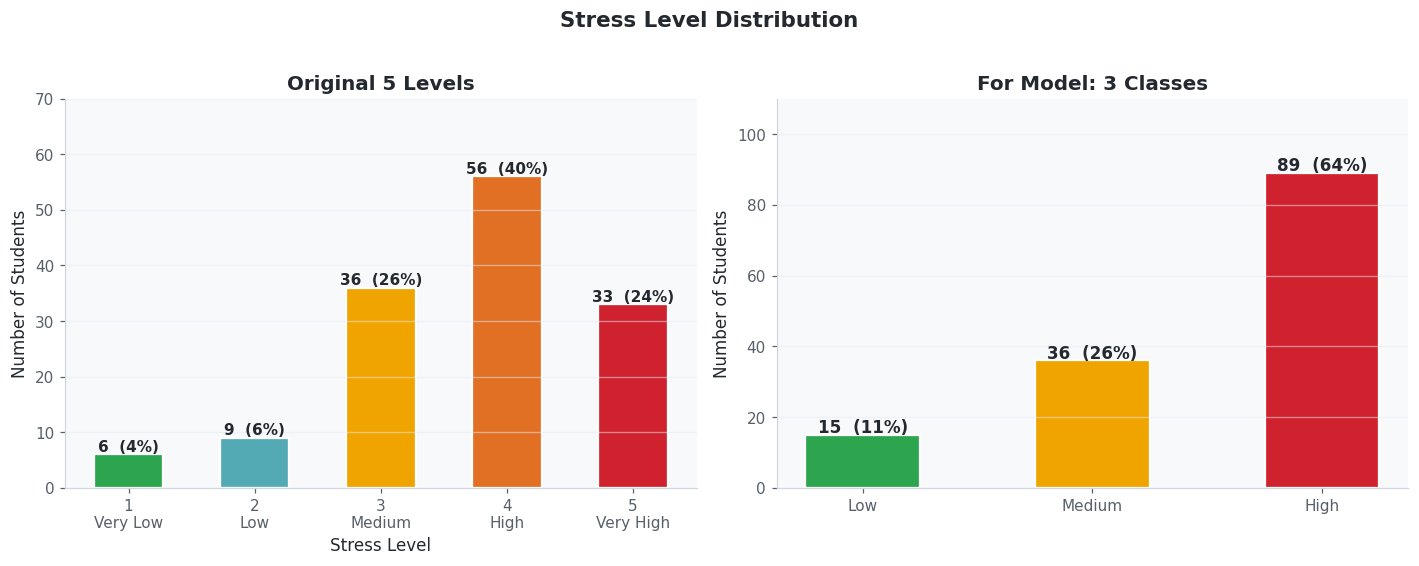

Saved → table_01_stress_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stress Level Distribution', fontsize=14, fontweight='bold', y=1.02)

# ── Left: original 5 levels ──
ax = axes[0]
count5 = df['stress_level'].value_counts().sort_index()
labels5 = ['1\nVery Low','2\nLow','3\nMedium','4\nHigh','5\nVery High']

bars = ax.bar(labels5, count5.values,
              color=[STRESS5_COLORS[i] for i in count5.index],
              edgecolor='white', linewidth=1.5, width=0.55)

for b, v in zip(bars, count5.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.6,
            f'{v}  ({v/len(df)*100:.0f}%)', ha='center',
            fontsize=10, fontweight='bold')

ax.set_title('Original 5 Levels')
ax.set_xlabel('Stress Level')
ax.set_ylabel('Number of Students')
ax.set_ylim(0, 70)
ax.grid(axis='y', alpha=0.5)

# ── Right: 3 classes (for model) ──
ax = axes[1]
count3 = df['stress_3'].value_counts().sort_index()

bars2 = ax.bar([STRESS3_NAMES[i] for i in count3.index], count3.values,
               color=[STRESS3_COLORS[i] for i in count3.index],
               edgecolor='white', linewidth=1.5, width=0.5)

for b, v in zip(bars2, count3.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.6,
            f'{v}  ({v/len(df)*100:.0f}%)', ha='center',
            fontsize=11, fontweight='bold')

ax.set_title('For Model: 3 Classes')
ax.set_ylabel('Number of Students')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('table_01_stress_distribution.png')
plt.show()

print('Saved → table_01_stress_distribution.png')

### 4.2 Демография: оқу деңгейі және зиянды әдеттер

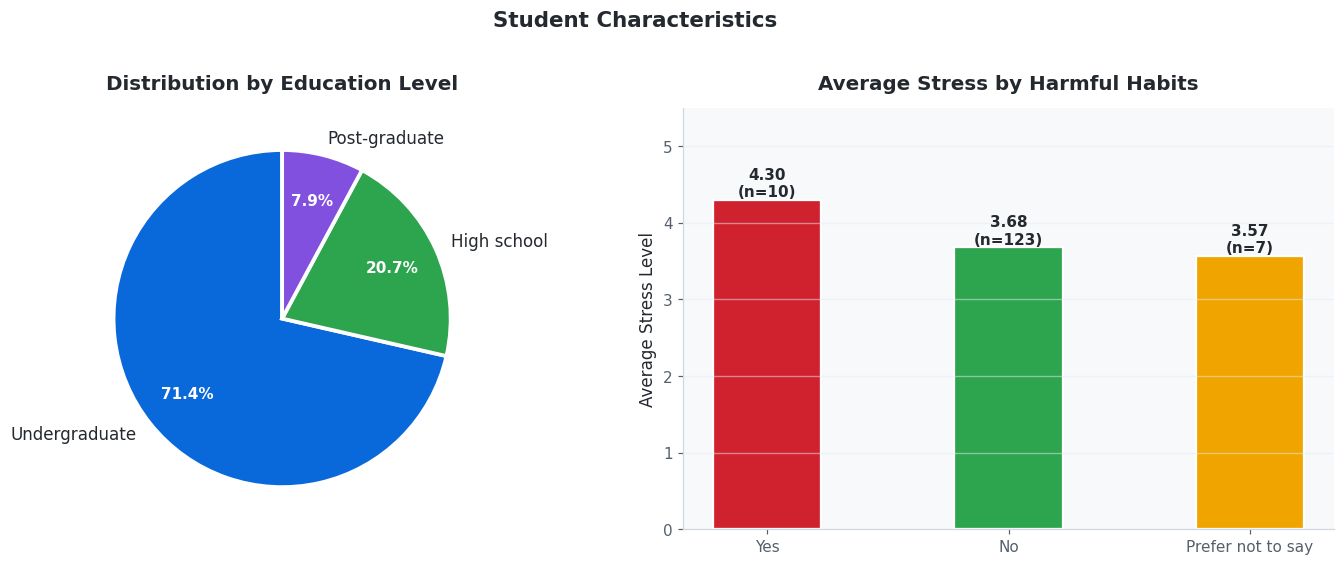

Saved → table_02_demographics.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Student Characteristics', fontsize=14, fontweight='bold', y=1.02)

# ── Left: distribution by education level ──
ax = axes[0]
level_count = df['level_eng'].value_counts()

_, texts, autotexts = ax.pie(
    level_count.values,
    labels=level_count.index,
    autopct='%1.1f%%',
    colors=['#0969DA', '#2DA44E', '#8250DF'],
    startangle=90,
    pctdistance=0.72,
    wedgeprops=dict(edgecolor='white', linewidth=2.5)
)

for t in texts:
    t.set_fontsize(11)

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('Distribution by Education Level', pad=12)

# ── Right: average stress by harmful habits ──
ax = axes[1]

habit_stress = df.groupby('harmful_habits')['stress_level'].mean().sort_values(ascending=False)
habit_count = df['harmful_habits'].value_counts()

habit_colors = {
    'No': '#2DA44E',
    'Yes': '#CF222E',
    'prefer not to say': '#F0A400'
}

habit_names = {
    'No': 'No',
    'Yes': 'Yes',
    'prefer not to say': 'Prefer not to say'
}

colors = [habit_colors.get(h, '#0969DA') for h in habit_stress.index]
names = [habit_names.get(h, h) for h in habit_stress.index]

bars = ax.bar(names, habit_stress.values,
              color=colors, edgecolor='white',
              linewidth=1.5, width=0.45)

for b, v, idx in zip(bars, habit_stress.values, habit_stress.index):
    n = habit_count.get(idx, 0)
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.04,
            f'{v:.2f}\n(n={n})',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('Average Stress by Harmful Habits', pad=12)
ax.set_ylabel('Average Stress Level')
ax.set_ylim(0, 5.5)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('table_02_demographics.png')
plt.show()

print('Saved → table_02_demographics.png')

### 4.3 Қысым мен бәсекелестік vs стресс

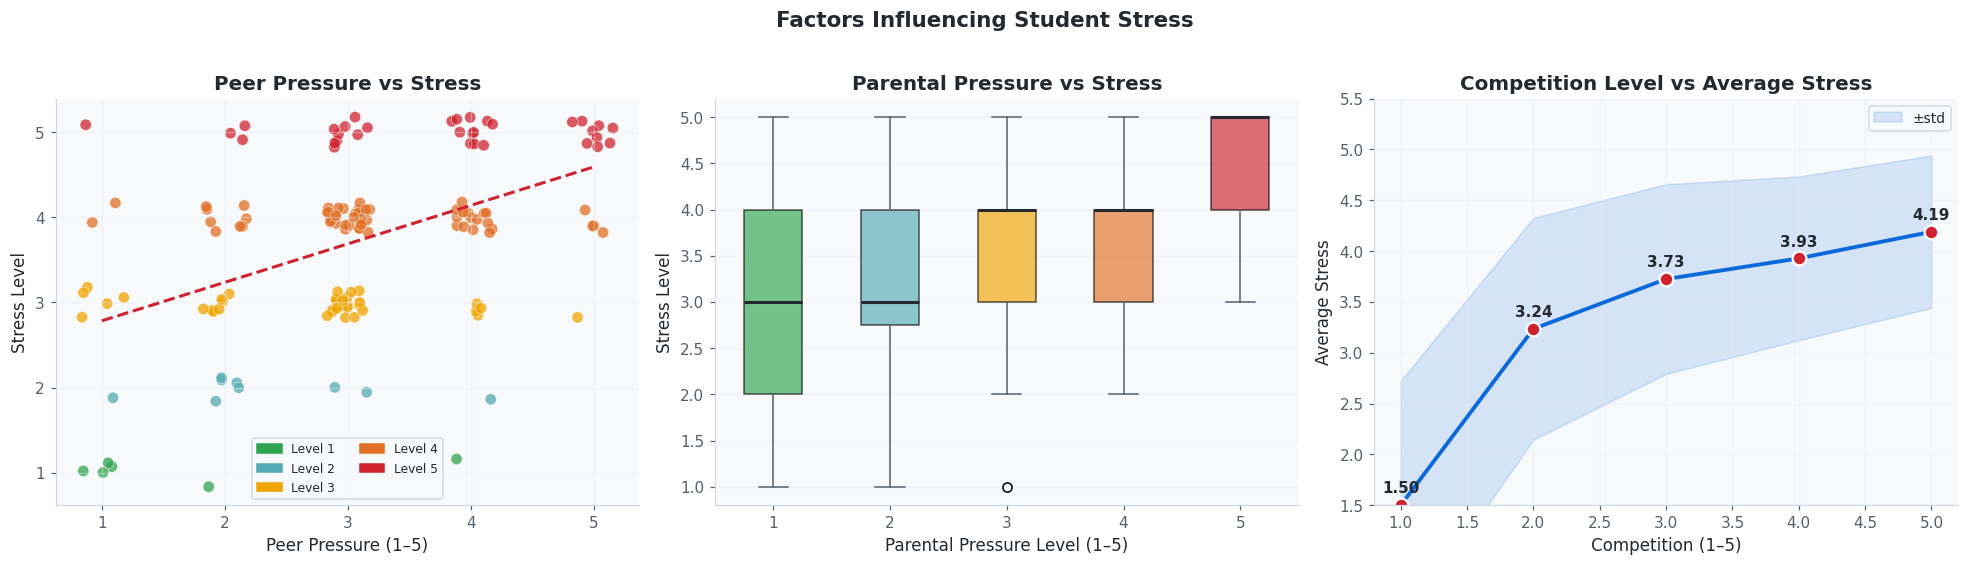

Saved → table_03_pressure_competition.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Factors Influencing Student Stress', fontsize=14, fontweight='bold', y=1.02)

# ── Peer pressure vs Stress ──
ax = axes[0]

scatter_colors = [STRESS5_COLORS[s] for s in df['stress_level']]

shift_x = df['peer_pressure'] + np.random.uniform(-0.18, 0.18, len(df))
shift_y = df['stress_level'] + np.random.uniform(-0.18, 0.18, len(df))

ax.scatter(shift_x, shift_y,
           c=scatter_colors,
           alpha=0.75,
           s=55,
           edgecolors='white',
           linewidth=0.4)

z = np.polyfit(df['peer_pressure'], df['stress_level'], 1)
x_line = np.linspace(1, 5, 100)

ax.plot(x_line,
        np.poly1d(z)(x_line),
        '--',
        color='#CF222E',
        linewidth=2,
        label='Trend')

ax.set_title('Peer Pressure vs Stress')
ax.set_xlabel('Peer Pressure (1–5)')
ax.set_ylabel('Stress Level')

legend_elements = [
    mpatches.Patch(color=STRESS5_COLORS[i], label=f'Level {i}')
    for i in range(1, 6)
]

ax.legend(handles=legend_elements, fontsize=8, ncol=2)
ax.grid(alpha=0.4)


# ── Parental pressure vs Stress ──
ax = axes[1]

parent_data = [
    df[df['parental_pressure'] == i]['stress_level'].values
    for i in sorted(df['parental_pressure'].unique())
]

parent_colors = ['#2DA44E', '#54AAB4', '#F0A400', '#E16F24', '#CF222E']

box = ax.boxplot(
    parent_data,
    labels=sorted(df['parental_pressure'].unique()),
    patch_artist=True,
    medianprops=dict(color='#24292F', linewidth=2)
)

for b, c in zip(box['boxes'], parent_colors):
    b.set_facecolor(c)
    b.set_alpha(0.65)

for whisker in box['whiskers']:
    whisker.set_color('#57606A')

for cap in box['caps']:
    cap.set_color('#57606A')

ax.set_title('Parental Pressure vs Stress')
ax.set_xlabel('Parental Pressure Level (1–5)')
ax.set_ylabel('Stress Level')
ax.grid(axis='y', alpha=0.4)


# ── Competition vs Average Stress ──
ax = axes[2]

competition_mean = df.groupby('competition')['stress_level'].mean()
competition_std = df.groupby('competition')['stress_level'].std()

ax.plot(
    competition_mean.index,
    competition_mean.values,
    'o-',
    color='#0969DA',
    linewidth=2.5,
    markersize=9,
    markerfacecolor='#CF222E',
    markeredgecolor='white',
    markeredgewidth=1.5
)

ax.fill_between(
    competition_mean.index,
    competition_mean.values - competition_std.values,
    competition_mean.values + competition_std.values,
    alpha=0.15,
    color='#0969DA',
    label='±std'
)

for x, y in zip(competition_mean.index, competition_mean.values):
    ax.text(x, y + 0.12, f'{y:.2f}', ha='center',
            fontsize=10, fontweight='bold')

ax.set_title('Competition Level vs Average Stress')
ax.set_xlabel('Competition (1–5)')
ax.set_ylabel('Average Stress')
ax.set_ylim(1.5, 5.5)
ax.legend()
ax.grid(alpha=0.4)


plt.tight_layout()
plt.savefig('table_03_pressure_competition.png')
plt.show()

print('Saved → table_03_pressure_competition.png')

### 4.4 Оқу ортасы және стресспен күресу стратегиялары

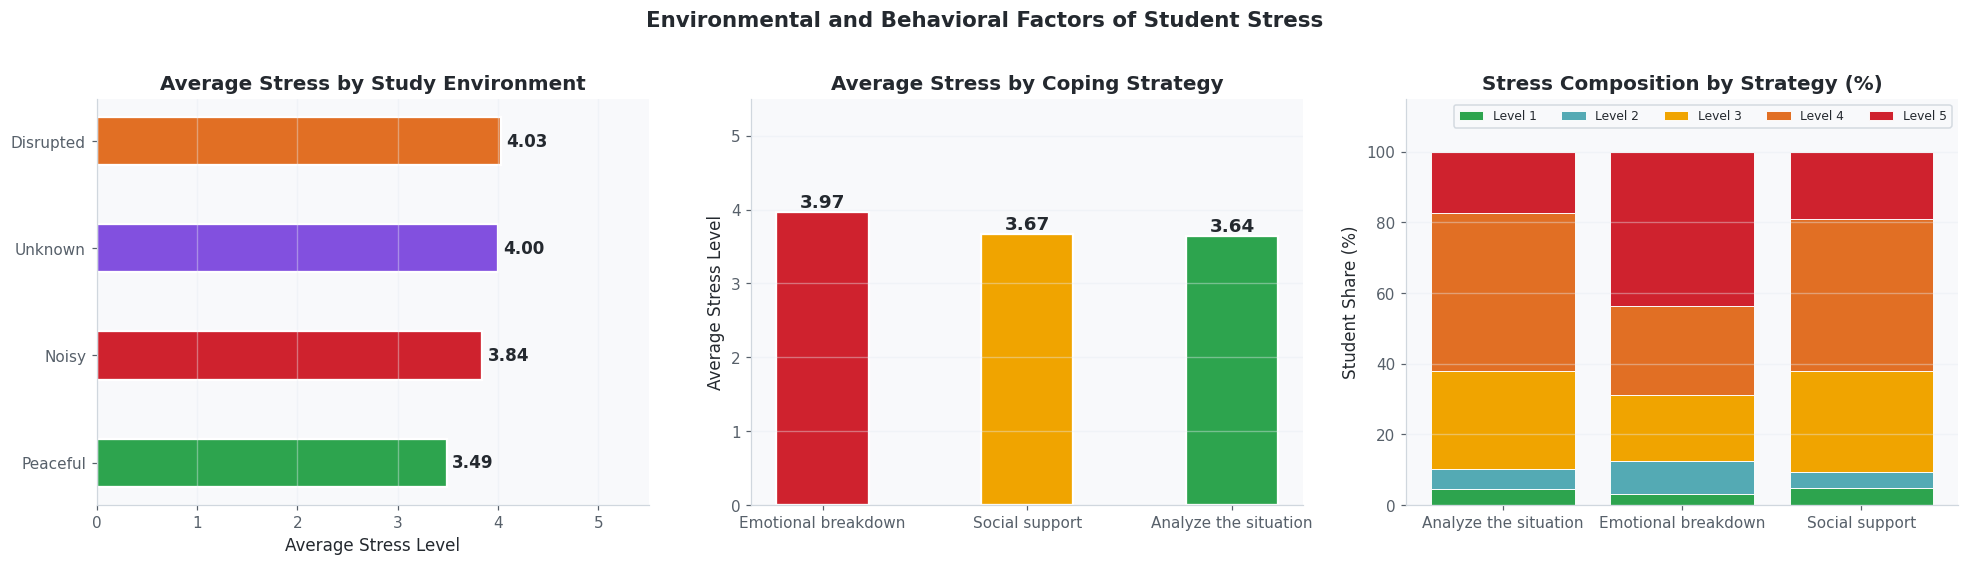

Saved → table_04_environment_strategy.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Environmental and Behavioral Factors of Student Stress',
             fontsize=14, fontweight='bold', y=1.02)

# ── Environment vs Average Stress ──
ax = axes[0]

environment_names = {
    'Peaceful': 'Peaceful',
    'Noisy': 'Noisy',
    'disrupted': 'Disrupted',
    'Unknown': 'Unknown'
}

environment_colors = {
    'Peaceful': '#2DA44E',
    'Noisy': '#CF222E',
    'disrupted': '#E16F24',
    'Unknown': '#8250DF'
}

environment_stress = df.groupby('environment')['stress_level'].mean().sort_values()

bars = ax.barh(
    [environment_names.get(e, e) for e in environment_stress.index],
    environment_stress.values,
    color=[environment_colors.get(e, '#0969DA') for e in environment_stress.index],
    edgecolor='white',
    linewidth=1.5,
    height=0.45
)

for b, v in zip(bars, environment_stress.values):
    ax.text(b.get_width() + 0.05,
            b.get_y() + b.get_height()/2,
            f'{v:.2f}',
            va='center',
            fontsize=11,
            fontweight='bold')

ax.set_title('Average Stress by Study Environment')
ax.set_xlabel('Average Stress Level')
ax.set_xlim(0, 5.5)
ax.grid(axis='x', alpha=0.4)


# ── Coping Strategy vs Average Stress ──
ax = axes[1]

strategy_stress = df.groupby('strategy_short')['stress_level'].mean().sort_values(ascending=False)

strategy_colors = {
    'Emotional breakdown': '#CF222E',
    'Analyze the situation': '#2DA44E',
    'Social support': '#F0A400'
}

bars2 = ax.bar(
    strategy_stress.index,
    strategy_stress.values,
    color=[strategy_colors.get(c, '#0969DA') for c in strategy_stress.index],
    edgecolor='white',
    linewidth=1.5,
    width=0.45
)

for b, v in zip(bars2, strategy_stress.values):
    ax.text(b.get_x() + b.get_width()/2,
            b.get_height() + 0.06,
            f'{v:.2f}',
            ha='center',
            fontsize=12,
            fontweight='bold')

ax.set_title('Average Stress by Coping Strategy')
ax.set_ylabel('Average Stress Level')
ax.set_ylim(0, 5.5)
ax.grid(axis='y', alpha=0.4)


# ── Stress composition by strategy (%) ──
ax = axes[2]

strategy_counts = df.groupby(['strategy_short', 'stress_level']).size().unstack(fill_value=0)
strategy_percent = strategy_counts.div(strategy_counts.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(strategy_percent))

for level in [1, 2, 3, 4, 5]:
    if level in strategy_percent.columns:
        ax.bar(
            strategy_percent.index,
            strategy_percent[level].values,
            bottom=bottom,
            color=STRESS5_COLORS[level],
            label=f'Level {level}',
            edgecolor='white',
            linewidth=0.6
        )
        bottom += strategy_percent[level].values

ax.set_title('Stress Composition by Strategy (%)')
ax.set_ylabel('Student Share (%)')
ax.set_ylim(0, 115)
ax.legend(ncol=5, loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.4)


plt.tight_layout()
plt.savefig('table_04_environment_strategy.png')
plt.show()

print('Saved → table_04_environment_strategy.png')

### 4.5 Сандық белгілердің корреляциясы

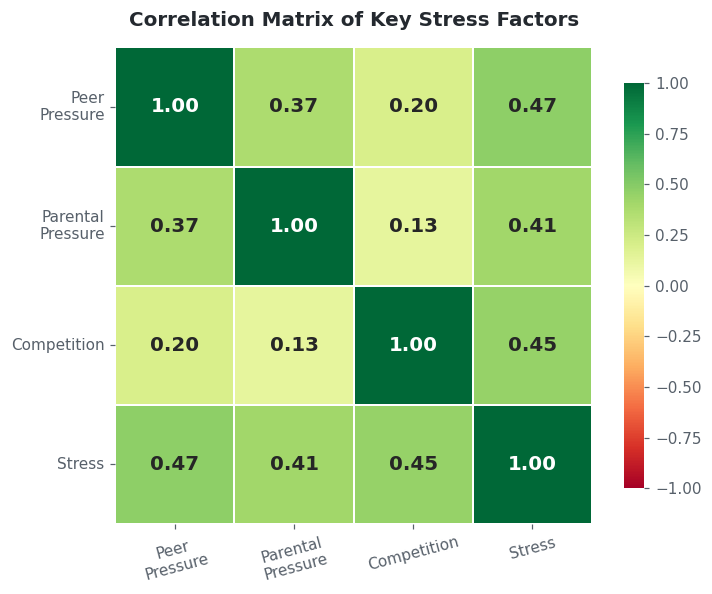

Saved → table_05_correlation.png


In [ ]:
numeric_cols = ['peer_pressure', 'parental_pressure', 'competition', 'stress_level']

corr_labels = [
    'Peer\nPressure',
    'Parental\nPressure',
    'Competition',
    'Stress'
]

corr = df[numeric_cols].corr()
corr.index = corr.columns = corr_labels

fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'shrink': 0.85}
)

ax.set_title('Correlation Matrix of Key Stress Factors', pad=14)

ax.tick_params(axis='x', rotation=15, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('table_05_correlation.png')
plt.show()

print('Saved → table_05_correlation.png')

---
## 5. Белгілерді дайындау

In [ ]:
# ── Label Encoding ──
le_level = LabelEncoder()
le_environment = LabelEncoder()
le_strategy = LabelEncoder()
le_habits = LabelEncoder()

df['level_enc'] = le_level.fit_transform(df['level'])
df['environment_enc'] = le_environment.fit_transform(df['environment'])
df['strategy_enc'] = le_strategy.fit_transform(df['strategy_short'])
df['habits_enc'] = le_habits.fit_transform(df['harmful_habits'])

# ── Feature Engineering — interaction features ──
df['total_pressure'] = df['peer_pressure'] + df['parental_pressure']
df['peer_x_competition'] = df['peer_pressure'] * df['competition']
df['parent_x_competition'] = df['parental_pressure'] * df['competition']

df['avg_stress_peer'] = df.groupby('peer_pressure')['stress_level'].transform('mean')
df['avg_stress_parent'] = df.groupby('parental_pressure')['stress_level'].transform('mean')

FEATURES = [
    'peer_pressure', 'parental_pressure', 'level_enc', 'environment_enc',
    'strategy_enc', 'habits_enc', 'competition',
    'total_pressure', 'peer_x_competition', 'parent_x_competition',
    'avg_stress_peer', 'avg_stress_parent'
]

print('Encodings:')
for le, name in [
    (le_level, 'level'),
    (le_environment, 'environment'),
    (le_strategy, 'strategy'),
    (le_habits, 'harmful_habits')
]:
    print(f'  {name}: {dict(enumerate(le.classes_))}')

print(f'\nTotal number of features: {len(FEATURES)}')
print('  Original: 7  |  Engineered: 5')

Encodings:
  level: {0: 'high school', 1: 'post-graduate', 2: 'undergraduate'}
  environment: {0: 'Noisy', 1: 'Peaceful', 2: 'Unknown', 3: 'disrupted'}
  strategy: {0: 'Analyze the situation', 1: 'Emotional breakdown', 2: 'Social support'}
  harmful_habits: {0: 'No', 1: 'Yes', 2: 'prefer not to say'}

Total number of features: 12
  Original: 7  |  Engineered: 5


In [ ]:
# ── Oversampling — balancing classes ──
max_count = df['stress_3'].value_counts().max()
parts = []

for cls in df['stress_3'].unique():
    d = df[df['stress_3'] == cls]
    if len(d) < max_count:
        d = resample(d, replace=True, n_samples=max_count, random_state=42)
    parts.append(d)

df_balanced = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)

print('After oversampling:')
for k, v in df_balanced['stress_3'].value_counts().sort_index().items():
    print(f'  {STRESS3_NAMES[k]}: {v}')

X = df_balanced[FEATURES].values
y = df_balanced['stress_3'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=7,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')

After oversampling:
  Low: 89
  Medium: 89
  High: 89

Train: 213 | Test: 54


---
## 6. Модельдерді оқыту

In [ ]:
MODELS = {
    'Extra Trees': (
        ExtraTreesClassifier(n_estimators=500, random_state=42), False
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42), False
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=500, random_state=42), False
    ),
    'SVM': (
        SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=42), True
    ),
    'Voting Ensemble': (
        VotingClassifier(estimators=[
            ('et', ExtraTreesClassifier(n_estimators=300, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=300, random_state=42)),
        ], voting='soft'), False
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":<22} {"Accuracy":>10} {"F1":>8} {"Precision":>10} {"Recall":>8} {"CV":>14}')
print('─' * 80)

for name, (model, scaled) in MODELS.items():
    Xtr = X_train_scaled if scaled else X_train
    Xte = X_test_scaled if scaled else X_test

    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')

    model.fit(Xtr, y_train)
    predictions = model.predict(Xte)

    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average='weighted')
    prec = precision_score(y_test, predictions, average='weighted', zero_division=0)
    rec = recall_score(y_test, predictions, average='weighted', zero_division=0)

    results[name] = dict(
        model=model,
        predictions=predictions,
        scaled=scaled,
        accuracy=acc,
        f1=f1,
        precision=prec,
        recall=rec,
        cv_mean=cv_scores.mean(),
        cv_std=cv_scores.std()
    )

    print(f'{name:<22} {acc:>10.3f} {f1:>8.3f} {prec:>10.3f} {rec:>8.3f}  {cv_scores.mean():.3f}±{cv_scores.std():.3f}')

best_name = max(results, key=lambda k: results[k]['accuracy'])

print(f'\nBest model: {best_name}  (Accuracy={results[best_name]["accuracy"]:.1%})')

Model                    Accuracy       F1  Precision   Recall             CV
────────────────────────────────────────────────────────────────────────────────
Extra Trees                 0.963    0.963      0.967    0.963  0.831±0.046
Gradient Boosting           0.889    0.885      0.893    0.889  0.854±0.031
Random Forest               0.889    0.885      0.893    0.889  0.812±0.050
SVM                         0.852    0.843      0.862    0.852  0.803±0.019
Voting Ensemble             0.907    0.905      0.909    0.907  0.845±0.033

Best model: Extra Trees  (Accuracy=96.3%)


### 7.1 Негізгі метрикалар

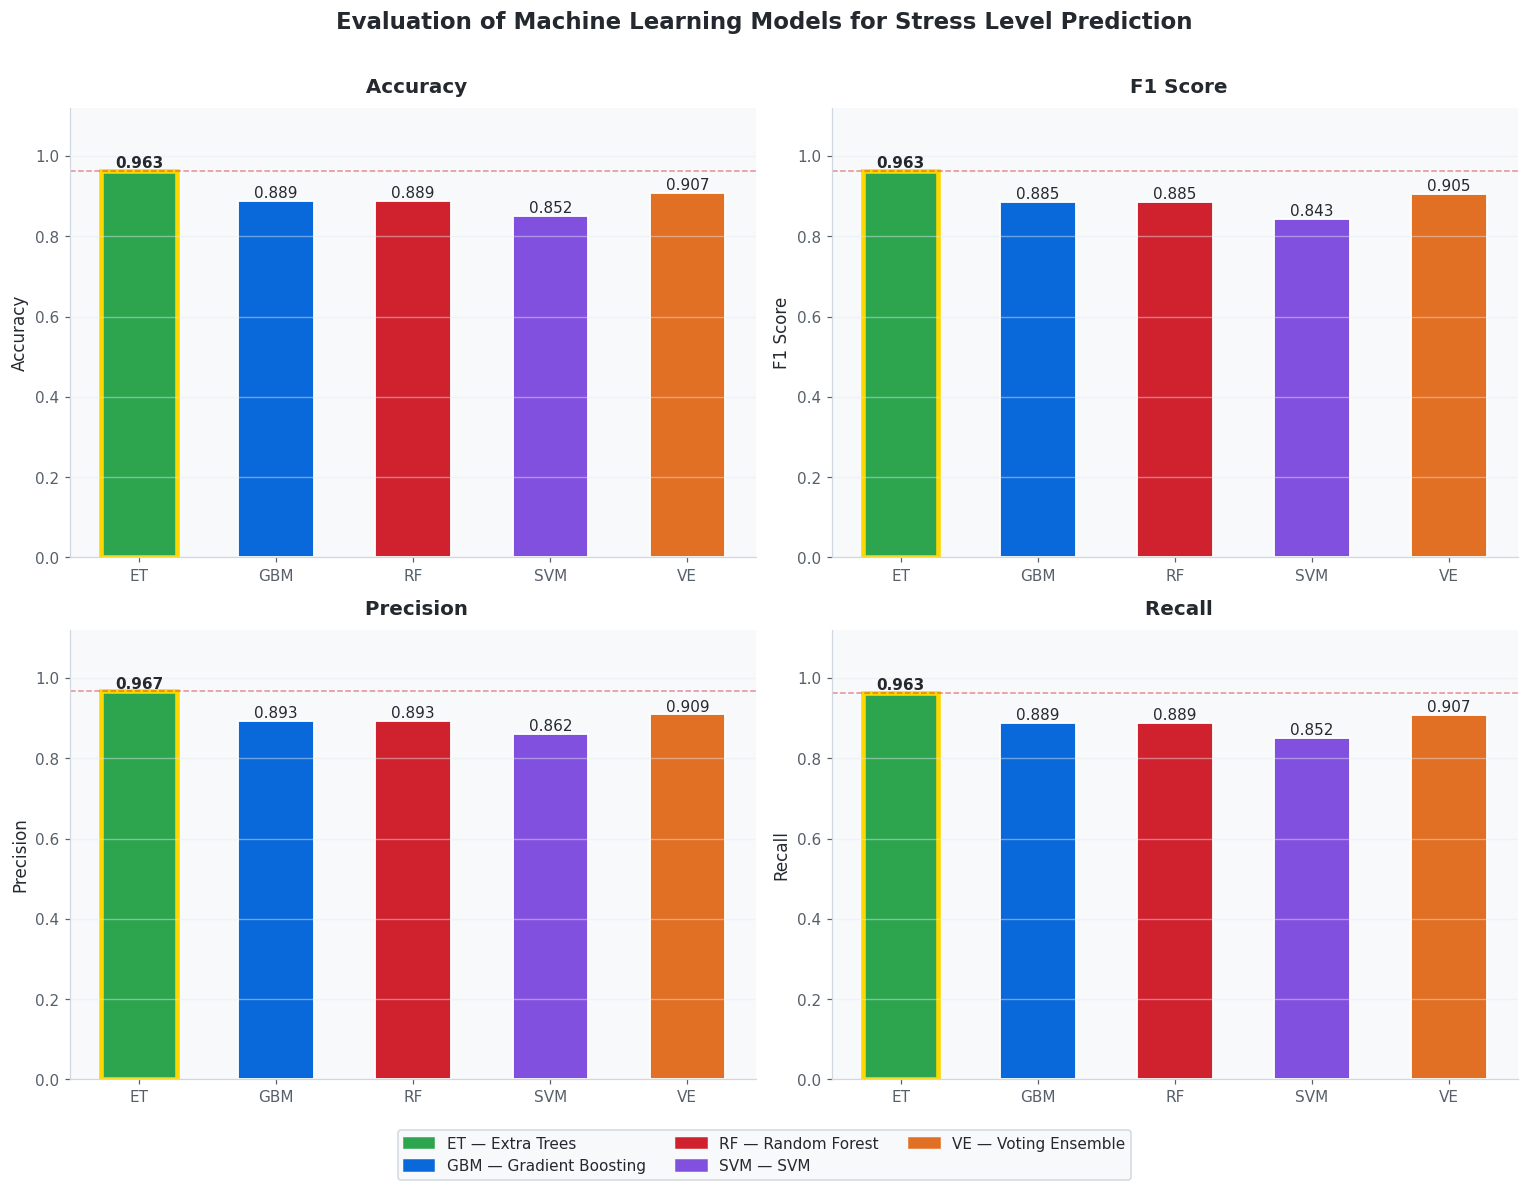

Saved → table_06_metrics.png


In [ ]:
model_names = list(results.keys())
short_names = ['ET', 'GBM', 'RF', 'SVM', 'VE']

bar_colors = [MODEL_COLORS[n] for n in model_names]

metrics_config = [
    ('accuracy',  'Accuracy',  ''),
    ('f1',        'F1 Score',  ''),
    ('precision', 'Precision', ''),
    ('recall',    'Recall',    ''),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluation of Machine Learning Models for Stress Level Prediction',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (metric, label, icon) in zip(axes.flat, metrics_config):

    values = [results[n][metric] for n in model_names]
    max_val = max(values)

    edge_colors = ['#FFD700' if v == max_val else 'white' for v in values]
    line_widths = [3.0 if v == max_val else 1.2 for v in values]

    bars = ax.bar(
        short_names,
        values,
        color=bar_colors,
        edgecolor=edge_colors,
        linewidth=line_widths,
        width=0.55
    )

    for b, v in zip(bars, values):
        ax.text(
            b.get_x() + b.get_width()/2,
            b.get_height() + 0.008,
            f'{v:.3f}',
            ha='center',
            fontsize=10,
            fontweight='bold' if v == max_val else 'normal'
        )

    ax.axhline(y=max_val, color='#CF222E',
               linestyle='--', linewidth=1, alpha=0.5)

    ax.set_title(f'{icon} {label}', pad=10)
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.12)
    ax.grid(axis='y', alpha=0.45)

legend_elements = [
    mpatches.Patch(color=MODEL_COLORS[n], label=f'{s} — {n}')
    for n, s in zip(model_names, short_names)
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.06),
    framealpha=0.95
)

plt.tight_layout()
plt.savefig('table_06_metrics.png')
plt.show()

print('Saved → table_06_metrics.png')

### 7.2 Cross-Validation (5-fold)

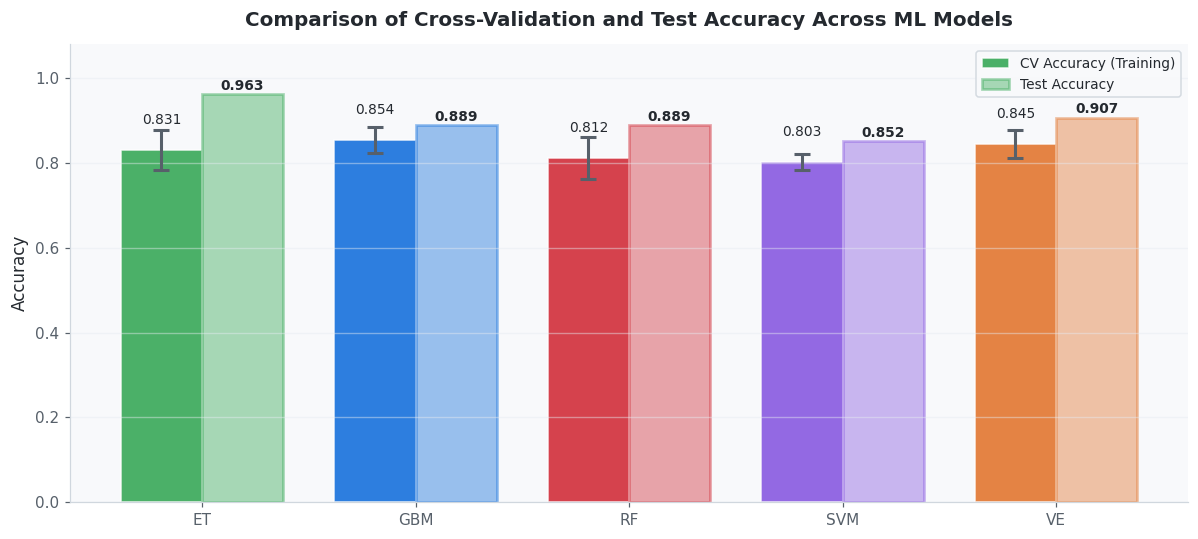

Saved → table_07_cv_vs_test.png


In [ ]:
cv_mean  = [results[n]['cv_mean'] for n in model_names]
cv_std   = [results[n]['cv_std']  for n in model_names]
test_acc = [results[n]['accuracy'] for n in model_names]

x = np.arange(len(model_names))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))

# Training CV Accuracy with error bars
ax.bar(
    x - w/2, cv_mean, w,
    color=bar_colors, alpha=0.85, edgecolor='white',
    yerr=cv_std, capsize=5,
    error_kw={'elinewidth':2, 'ecolor':'#57606A', 'capthick':2},
    label='CV Accuracy (Training)'
)

# Test Accuracy
ax.bar(
    x + w/2, test_acc, w,
    color=bar_colors, alpha=0.4,
    edgecolor=bar_colors, linewidth=1.8,
    label='Test Accuracy'
)

# Add values above bars
for i, (cv, test) in enumerate(zip(cv_mean, test_acc)):
    ax.text(i - w/2, cv + max(cv_std) + 0.012, f'{cv:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, test + 0.01, f'{test:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.08)
ax.set_title('Comparison of Cross-Validation and Test Accuracy Across ML Models', pad=12)
ax.legend()
ax.grid(axis='y', alpha=0.45)

plt.tight_layout()
plt.savefig('table_07_cv_vs_test.png')
plt.show()

print('Saved → table_07_cv_vs_test.png')

### 7.3 Қателік матрицалары — барлық модельдер

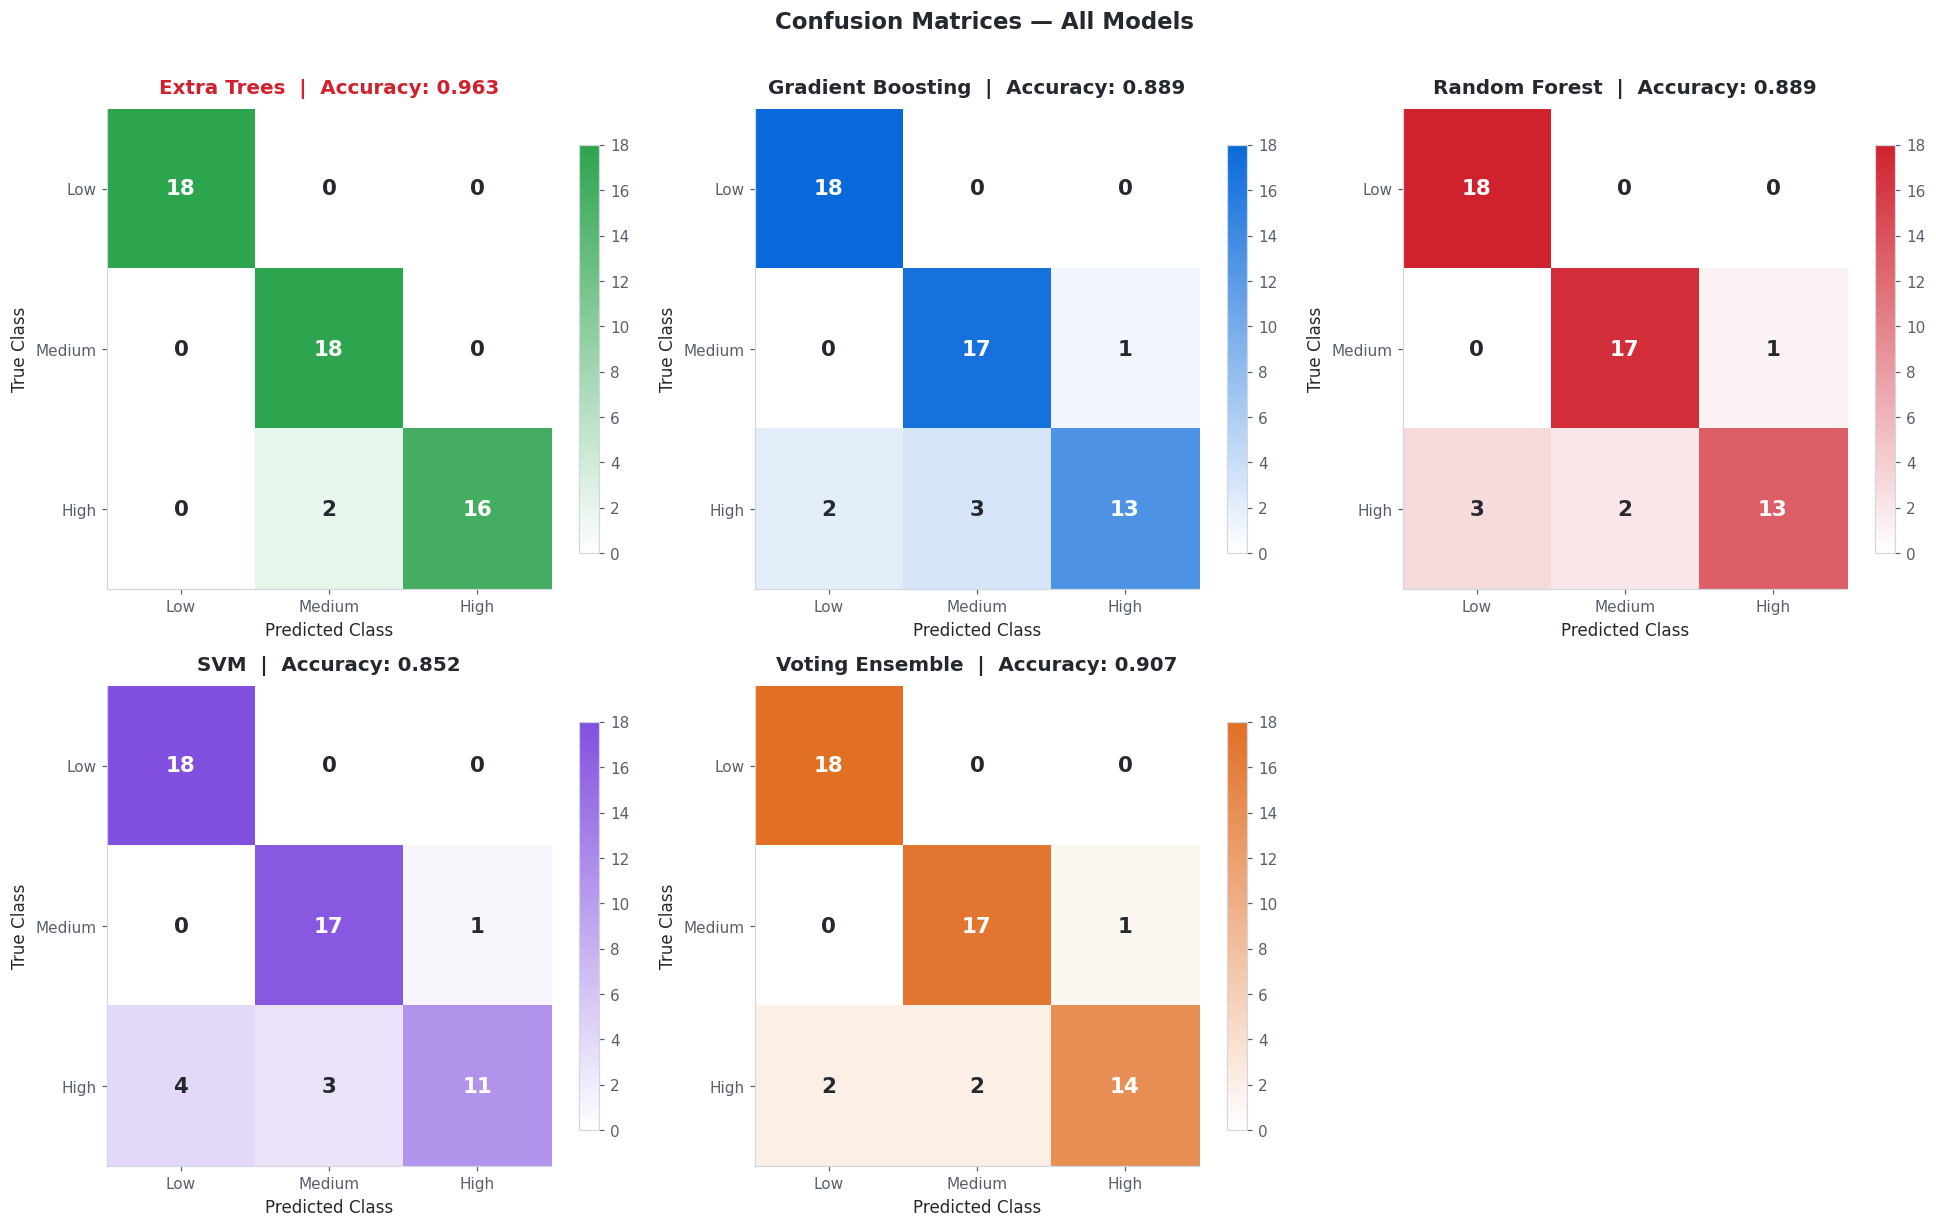

Saved → table_08_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes[1][2].set_visible(False)  # Hide the empty subplot
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)

plot_axes = [axes[0][0], axes[0][1], axes[0][2], axes[1][0], axes[1][1]]
cm_labels = [STRESS3_NAMES[i] for i in range(3)]

for idx, model_name in enumerate(model_names):
    ax = plot_axes[idx]
    cm = confusion_matrix(y_test, results[model_name]['predictions'])
    cmap = LinearSegmentedColormap.from_list('c', ['#FFFFFF', MODEL_COLORS[model_name]], N=256)
    im = ax.imshow(cm, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)

    for i in range(3):
        for j in range(3):
            color = 'white' if cm[i, j] > cm.max()*0.55 else '#24292F'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(cm_labels)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(cm_labels)
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')

    highlight = ''  # optional symbol for best model
    title_color = '#CF222E' if model_name == best_name else '#24292F'
    ax.set_title(f'{model_name}{highlight}  |  Accuracy: {results[model_name]["accuracy"]:.3f}',
                 color=title_color, pad=10)

plt.tight_layout()
plt.savefig('table_08_confusion_matrices.png')
plt.show()
print('Saved → table_08_confusion_matrices.png')

### 8.1 Толық есеп және Radar диаграммасы

In [ ]:
print(f'Full Report — {best_name}')
print('='*55)
print(classification_report(
    y_test, results[best_name]['predictions'],
    target_names=['Low (1–2)', 'Medium (3)', 'High (4–5)']
))

Full Report — Extra Trees
              precision    recall  f1-score   support

   Low (1–2)       1.00      1.00      1.00        18
  Medium (3)       0.90      1.00      0.95        18
  High (4–5)       1.00      0.89      0.94        18

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



### 8.2 Белгілердің маңыздылығы (Extra Trees)

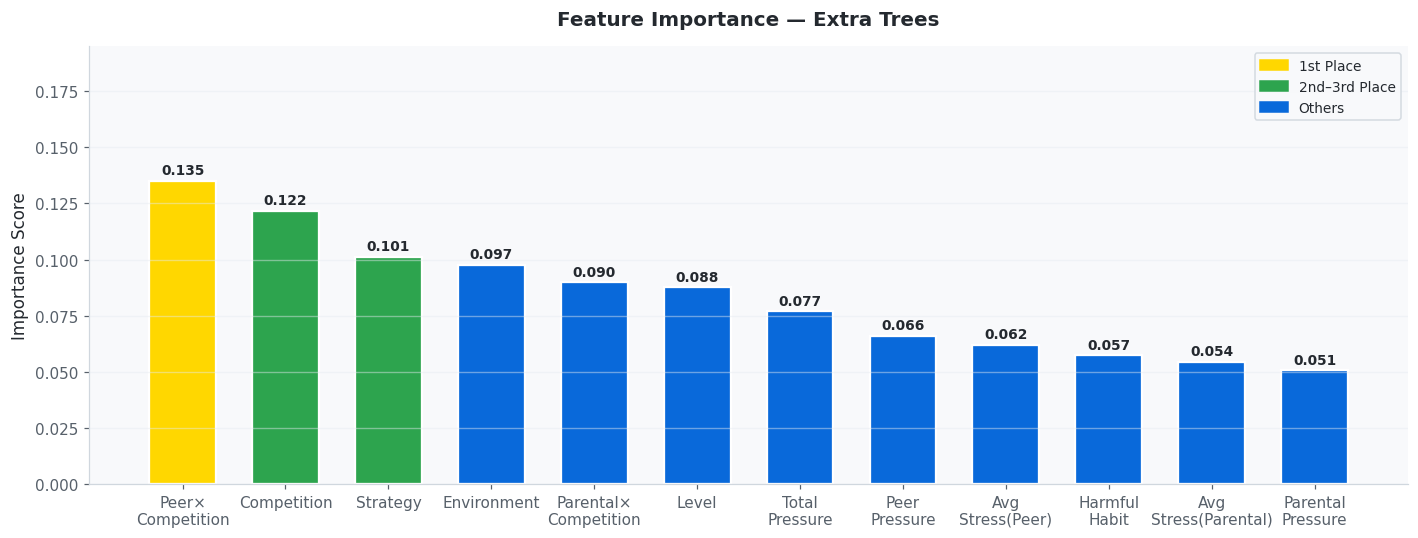

Saved → table_10_feature_importance.png


In [ ]:
et_model   = results['Extra Trees']['model']
feature_names = [
    'Peer\nPressure','Parental\nPressure','Level','Environment',
    'Strategy','Harmful\nHabit','Competition',
    'Total\nPressure','Peer×\nCompetition','Parental×\nCompetition',
    'Avg\nStress(Peer)','Avg\nStress(Parental)'
]
importance = et_model.feature_importances_
sorted_idx = np.argsort(importance)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_values = importance[sorted_idx]

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#FFD700' if i == 0 else '#2DA44E' if i <= 2 else '#0969DA'
          for i in range(len(sorted_values))]
bars = ax.bar(sorted_names, sorted_values, color=colors, edgecolor='white', linewidth=1.5, width=0.65)

for b, v in zip(bars, sorted_values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title(f'Feature Importance — {best_name}', pad=14)
ax.set_ylabel('Importance Score')
ax.set_ylim(0, sorted_values[0]+0.06)
ax.grid(axis='y', alpha=0.45)
ax.legend(handles=[
    mpatches.Patch(color='#FFD700', label='1st Place'),
    mpatches.Patch(color='#2DA44E', label='2nd–3rd Place'),
    mpatches.Patch(color='#0969DA', label='Others'),
])

plt.tight_layout()
plt.savefig('table_10_feature_importance.png')
plt.show()
print('Saved → table_10_feature_importance.png')

---
## 9. Модельді сақтау

In [ ]:
import joblib
import json
import numpy as np

# ── Save trained model and scaler ──
joblib.dump(results[best_name]['model'], 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# ── Save encoder and metadata info ──
encoder_info = {
    'best_name':      best_name,
    'task':            '3 classes: 0=Low(1-2), 1=Medium(3), 2=High(4-5)',
    'features':        FEATURES,
    'stage_classes':   le_level.classes_.tolist(),
    'env_classes':     le_environment.classes_.tolist(),
    'coping_classes':  le_strategy.classes_.tolist(),
    'habits_classes':  le_habits.classes_.tolist(),
    'level_classes':   le_level.classes_.tolist(),
    'env_classes_alt': le_environment.classes_.tolist(),
    'strategy_classes':le_strategy.classes_.tolist(),
    'habits_classes_alt': le_habits.classes_.tolist(),
    'metrics': {
        'accuracy':    round(results[best_name]['accuracy'], 4),
        'f1':          round(results[best_name]['f1'],       4),
        'precision':   round(results[best_name]['precision'],4),
        'recall':      round(results[best_name]['recall'],   4),
    }
}

with open('encoder_info.json', 'w', encoding='utf-8') as f:
    json.dump(encoder_info, f, ensure_ascii=False, indent=2)

# ── Test prediction ──
loaded_model = joblib.load('best_model.pkl')
sample = np.array([[4, 5, 2, 0, 0, 0, 4, 9, 16, 20, 3.8, 4.1]])
prediction = loaded_model.predict(sample)
label = STRESS3_NAMES[prediction[0]]

print('Saved files:')
print('   best_model.pkl    — trained model')
print('   scaler.pkl        — scaler')
print('   encoder_info.json — encoders & mappings')
print(f'\nTest prediction: {label} (class {prediction[0]})')
print(f'\nBest model: {best_name}')
print(f'   Accuracy  = {results[best_name]["accuracy"]:.3f}')
print(f'   F1 Score  = {results[best_name]["f1"]:.3f}')
print(f'   Precision = {results[best_name]["precision"]:.3f}')
print(f'   Recall    = {results[best_name]["recall"]:.3f}')
print('\nAnalysis complete! All files saved.')

Saved files:
   best_model.pkl    — trained model
   scaler.pkl        — scaler
   encoder_info.json — encoders & mappings

Test prediction: High (class 2)

Best model: Extra Trees
   Accuracy  = 0.963
   F1 Score  = 0.963
   Precision = 0.967
   Recall    = 0.963

Analysis complete! All files saved.
